In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

In [3]:
from pathlib import Path
import pandas as pd

train_p = Path(r".\Data_v2\Bootstrapped_Audios\FeaturesTable\train_df.csv")
test_p = Path(r".\Data_v2\Bootstrapped_Audios\FeaturesTable\test_df.csv")
train_df = pd.read_csv(train_p)
test_df = pd.read_csv(test_p)

In [4]:
X_train = train_df.drop(columns=["filepath", "label"])
y_train = train_df["label"]

X_test = test_df.drop(columns=["filepath", "label"])
y_test = test_df["label"]

Batch Cross Validation

In [5]:
clf = RandomForestClassifier(n_estimators=200) #parameter tuning possible
 
cv = StratifiedKFold(n_splits=10, shuffle=True)
scoring = ["accuracy", "f1_macro", "precision_macro", "recall_macro"]
 
cv_results = cross_validate(
    clf, X_train, y_train,
    cv=cv, scoring=scoring, return_train_score=True, n_jobs=-1
)
 
print("=== Cross-Validation Results (10-fold) ===")
for metric in scoring:
    scores = cv_results[f"test_{metric}"]
    print(f"{metric:15s}: mean={scores.mean():.4f}  std={scores.std():.4f}  folds={np.round(scores,3)}")
 

=== Cross-Validation Results (10-fold) ===
accuracy       : mean=0.9114  std=0.0298  folds=[0.9   0.929 0.886 0.914 0.943 0.971 0.871 0.871 0.914 0.914]
f1_macro       : mean=0.9109  std=0.0300  folds=[0.898 0.93  0.886 0.915 0.941 0.971 0.871 0.87  0.913 0.914]
precision_macro: mean=0.9165  std=0.0298  folds=[0.911 0.934 0.897 0.92  0.951 0.974 0.872 0.876 0.917 0.914]
recall_macro   : mean=0.9109  std=0.0302  folds=[0.898 0.929 0.884 0.913 0.941 0.972 0.871 0.871 0.916 0.914]


Test on Unseen Data

In [6]:
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)

class_names = {'Explosion': 0, 'Gunshots': 1, 'UAV': 2, 'shortened_unlabeled': 3}
target_names = [name for name, idx in sorted(class_names.items(), key=lambda x: x[1])]

print("\n=== Final Held-Out Test ===")
print(f"Test Accuracy: {test_acc:.4f}")
print(classification_report(y_test, y_pred, target_names=target_names))


=== Final Held-Out Test ===
Test Accuracy: 0.6933
                     precision    recall  f1-score   support

          Explosion       0.57      0.73      0.64        75
           Gunshots       0.65      0.43      0.52        75
                UAV       1.00      0.63      0.77        75
shortened_unlabeled       0.69      0.99      0.81        75

           accuracy                           0.69       300
          macro avg       0.73      0.69      0.68       300
       weighted avg       0.73      0.69      0.68       300



Visualize


=== Final Held-Out Test ===
Test Accuracy: 0.6833
                     precision    recall  f1-score   support

          Explosion       0.57      0.69      0.62        75
           Gunshots       0.62      0.40      0.49        75
                UAV       0.98      0.67      0.79        75
shortened_unlabeled       0.67      0.97      0.79        75

           accuracy                           0.68       300
          macro avg       0.71      0.68      0.67       300
       weighted avg       0.71      0.68      0.67       300



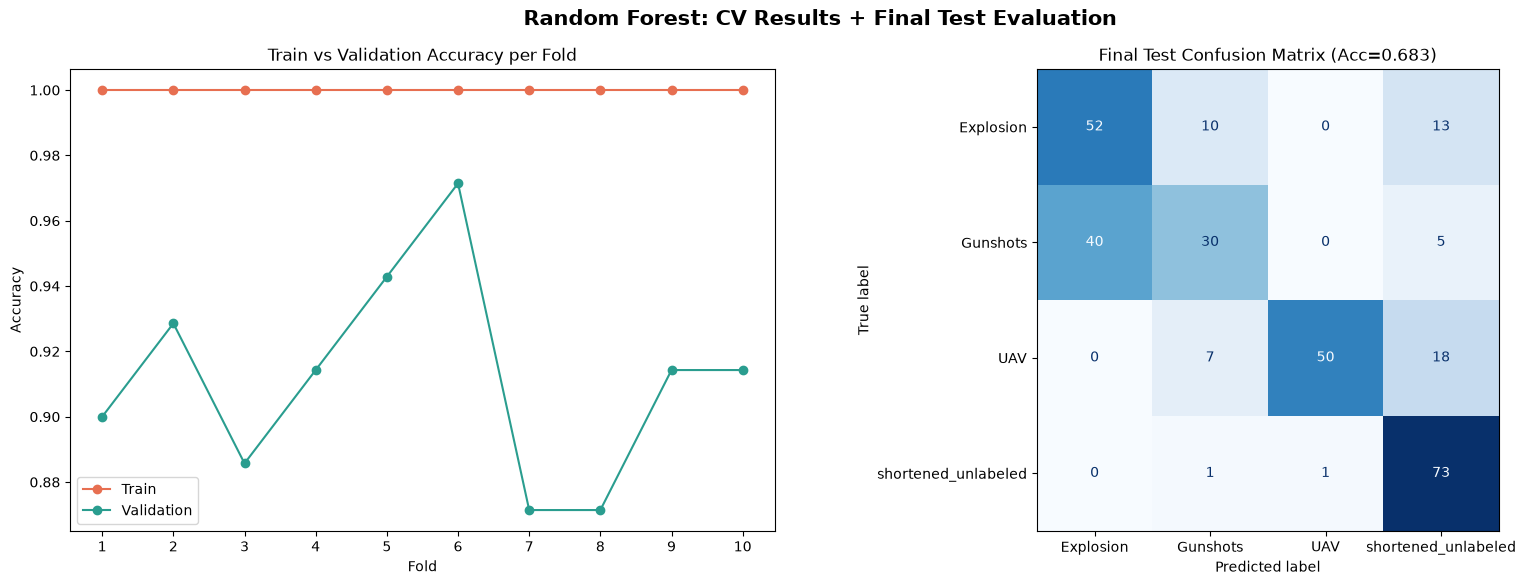

In [7]:
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)

target_names = [name for name, idx in sorted(class_names.items(), key=lambda x: x[1])]

print("\n=== Final Held-Out Test ===")
print(f"Test Accuracy: {test_acc:.4f}")
print(classification_report(y_test, y_pred, target_names=target_names))

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
fig.suptitle("Random Forest: CV Results + Final Test Evaluation", fontsize=15, fontweight="bold")

# Train vs validation accuracy per fold (overfitting check)
ax = axes[0]
folds = np.arange(1, len(cv_results["test_accuracy"]) + 1)
ax.plot(folds, cv_results["train_accuracy"], marker="o", label="Train", color="#e76f51")
ax.plot(folds, cv_results["test_accuracy"], marker="o", label="Validation", color="#2a9d8f")
ax.set_xticks(folds)
ax.set_xlabel("Fold")
ax.set_ylabel("Accuracy")
ax.set_title("Train vs Validation Accuracy per Fold")
ax.legend()

# Confusion matrix on final held-out test set
ax = axes[1]
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Final Test Confusion Matrix (Acc={test_acc:.3f})")
plt.tight_layout

# Feature importances (from final fitted model)
feature_names = X_train.columns   # <-- feature columns only, matches clf.feature_importances_ length
importances = clf.feature_importances_
order = np.argsort(importances)


Feature Importance

In [8]:
""" 
Random Forest feature importance captures how much the feature contributes to reducing the impurity score / error.
"""

' \nRandom Forest feature importance captures how much the feature contributes to reducing the impurity score / error.\n'

In [9]:
def top_features_by_cumulative_importance(clf, feature_names, threshold=0.90):
    importances = clf.feature_importances_
    order = np.argsort(importances)[::-1]
    sorted_importances = importances[order]
    sorted_names = np.array(feature_names)[order]
    cumulative = np.cumsum(sorted_importances)
    n_features = np.searchsorted(cumulative, threshold) + 1
    return pd.DataFrame({
        "feature": sorted_names[:n_features],
        "importance": sorted_importances[:n_features],
        "cumulative": cumulative[:n_features]
    })

top_features_by_cumulative_importance(clf, X_train.columns, threshold=0.90)

,feature,importance,cumulative
0,temporal_centroid,0.037115,0.037115
1,rms_std,0.032540,0.069655
2,rms_max,0.030493,0.100148
3,attack_time,0.021570,0.121718
4,band_high_ratio,0.018234,0.139953
...,...,...,...
142,delta_10_max,0.002531,0.891201
143,delta_4_min,0.002513,0.893714
144,rolloff_mean,0.002506,0.896219
145,mfcc_10_std,0.002498,0.898717


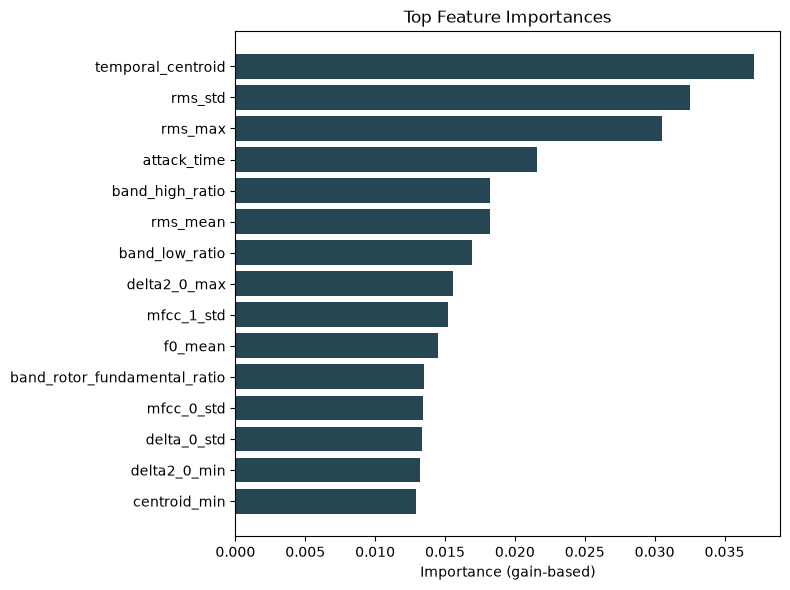

In [10]:
feature_names = X_train.columns
importances = clf.feature_importances_
order = np.argsort(importances)[-15:]   # top 15 features

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(range(len(order)), importances[order], color="#264653")
ax.set_yticks(range(len(order)))
ax.set_yticklabels(feature_names[order])
ax.set_xlabel("Importance (gain-based)")
ax.set_title("Top Feature Importances")
plt.tight_layout()
plt.show()

Parameter Tuning

In [11]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np

# -----------------------------
# 1. Define search space
# -----------------------------
param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None],
    "class_weight": [None, "balanced", "balanced_subsample"]
}

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# -----------------------------
# 2. Run randomized search
#    scoring="f1_macro" weighs weak classes (like Gunshots) equally,
#    instead of letting accuracy hide behind the strong classes
# -----------------------------
random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=50,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search.fit(X_train, y_train)

print("Best params:", random_search.best_params_)
print("Best CV f1_macro score:", random_search.best_score_)

clf_tuned = random_search.best_estimator_

# -----------------------------
# 3. Compare tuned vs default model on the SAME untouched test set
# -----------------------------
clf_default = RandomForestClassifier(n_estimators=200, random_state=42)
clf_default.fit(X_train, y_train)

for name, model in [("Default", clf_default), ("Tuned", clf_tuned)]:
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n=== {name} Model — Final Held-Out Test ===")
    print(f"Test Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=target_names))

    cm = confusion_matrix(y_test, y_pred)
    recall_per_class = cm.diagonal() / cm.sum(axis=1)
    print(f"Per-class recall ({name}):")
    for cname, r in zip(target_names, recall_per_class):
        print(f"  {cname:25s}: {r:.4f}")

Fitting 10 folds for each of 50 candidates, totalling 500 fits
Best params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 10, 'class_weight': None}
Best CV f1_macro score: 0.9339975859983601

=== Default Model — Final Held-Out Test ===
Test Accuracy: 0.7000
                     precision    recall  f1-score   support

          Explosion       0.58      0.69      0.63        75
           Gunshots       0.65      0.44      0.52        75
                UAV       1.00      0.68      0.81        75
shortened_unlabeled       0.68      0.99      0.80        75

           accuracy                           0.70       300
          macro avg       0.73      0.70      0.69       300
       weighted avg       0.73      0.70      0.69       300

Per-class recall (Default):
  Explosion                : 0.6933
  Gunshots                 : 0.4400
  UAV                      : 0.6800
  shortened_unlabeled      : 0.9867

=== Tuned Model — Fi